Split Test

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_excel('/content/Project_KDKA/processed.cleveland 1.xlsx')
df.replace('?', np.nan, inplace=True)

df = df.apply(pd.to_numeric, errors='coerce')

df.dropna(inplace=True)

print(f"Total baris setelah remove missing: {len(df)}")

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x > 0 else 0)

print("\n             DATA SPLIT")
print("----------------------------------------")
print(f" Nilai unik target sebelum : {df.iloc[:, -1].unique()}")
print(f" Nilai unik target sesudah : {y.unique()}")
print("----------------------------------------")
print(f"         Distribusi Target")
print("----------------------------------------")
print(f" Sehat (0)           : {(y==0).sum()} pasien")
print(f" Penyakit jantung (1): {(y==1).sum()} pasien")
print(" ---------------------------------------")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nJumlah data train : {X_train.shape[0]}")
print(f"Jumlah data test  : {X_test.shape[0]}")

print("\nDISTRIBUSI TARGET TRAIN ")
print(y_train.value_counts())

print("\nDISTRIBUSI TARGET TEST ")
print(y_test.value_counts())

Total baris setelah remove missing: 297

             DATA SPLIT
----------------------------------------
 Nilai unik target sebelum : [0 2 1 3 4]
 Nilai unik target sesudah : [0 1]
----------------------------------------
         Distribusi Target
----------------------------------------
 Sehat (0)           : 160 pasien
 Penyakit jantung (1): 137 pasien
 ---------------------------------------

Jumlah data train : 237
Jumlah data test  : 60

DISTRIBUSI TARGET TRAIN 
 target
0    128
1    109
Name: count, dtype: int64

DISTRIBUSI TARGET TEST 
 target
0    32
1    28
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel('/content/Project_KDKA/processed.cleveland 1.xlsx')
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

cols_to_check = [' slope', ' ca', ' cp', ' restecg', ' thal']

for col in cols_to_check:
    print(f"\n{'='*40}")
    print(f"Kolom: {col}")
    print(f"Nilai unik: {sorted(df[col].unique())}")
    counts = df[col].value_counts().sort_index()
    total = len(df)

    print(f"\n{'Nilai':<10} {'Jumlah':<10} {'Persentase'}")
    print(f"{'-'*30}")
    for val, count in counts.items():
        pct = (count / total) * 100
        print(f"{val:<10} {count:<10} {pct:.1f}%")


Kolom:  slope
Nilai unik: [np.int64(1), np.int64(2), np.int64(3)]

Nilai      Jumlah     Persentase
------------------------------
1          139        46.8%
2          137        46.1%
3          21         7.1%

Kolom:  ca
Nilai unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Nilai      Jumlah     Persentase
------------------------------
0          174        58.6%
1          65         21.9%
2          38         12.8%
3          20         6.7%

Kolom:  cp
Nilai unik: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Nilai      Jumlah     Persentase
------------------------------
1          23         7.7%
2          49         16.5%
3          83         27.9%
4          142        47.8%

Kolom:  restecg
Nilai unik: [np.int64(0), np.int64(1), np.int64(2)]

Nilai      Jumlah     Persentase
------------------------------
0          147        49.5%
1          4          1.3%
2          146        49.2%

Kolom:  thal
Nilai unik: [np.int64(3), np.int64(6), np.int64(

Outlier

In [ ]:
import joblib
iqr_bounds = {}
num_cols = ['age', ' chol', ' trestbps', ' thalach', ' oldpeak']

for col in num_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_bounds[col] = (lower, upper)

    before_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    before_test = ((X_test[col] < lower) | (X_test[col] > upper)).sum()

    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

    after_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    after_test = ((X_test[col] < lower) | (X_test[col] > upper)).sum()

    print(f"""
    Feature             : {col}
    Q1                  : {Q1:.2f}
    Q3                  : {Q3:.2f}
    IQR                 : {IQR:.2f}
    Lower               : {lower:.2f}
    Upper               : {upper:.2f}

    TRAIN Outlier Before: {before_train}
    TRAIN Outlier After : {after_train}

    TEST Outlier Before : {before_test}
    TEST Outlier After  : {after_test}
    """)

joblib.dump(iqr_bounds, 'iqr_bounds.pkl')


    Feature             : age
    Q1                  : 48.00
    Q3                  : 62.00
    IQR                 : 14.00
    Lower               : 27.00
    Upper               : 83.00

    TRAIN Outlier Before: 0
    TRAIN Outlier After : 0

    TEST Outlier Before : 0
    TEST Outlier After  : 0
    

    Feature             :  chol
    Q1                  : 212.00
    Q3                  : 277.00
    IQR                 : 65.00
    Lower               : 114.50
    Upper               : 374.50

    TRAIN Outlier Before: 5
    TRAIN Outlier After : 0

    TEST Outlier Before : 0
    TEST Outlier After  : 0
    

    Feature             :  trestbps
    Q1                  : 120.00
    Q3                  : 140.00
    IQR                 : 20.00
    Lower               : 90.00
    Upper               : 170.00

    TRAIN Outlier Before: 7
    TRAIN Outlier After : 0

    TEST Outlier Before : 2
    TEST Outlier After  : 0
    

    Feature             :  thalach
    Q1             

['iqr_bounds.pkl']

Encoding

In [ ]:
X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()

X_train = pd.get_dummies(X_train, columns=['cp', 'restecg', 'thal'], drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=['cp', 'restecg', 'thal'], drop_first=False)

# Samakan kolom train dan test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print(f"Shape X_train setelah encoding: {X_train.shape}")
print(f"Shape X_test  setelah encoding: {X_test.shape}")

print("\nKolom X_train:")
for col in X_train.columns:
    print(f"  - {col}")

print("\nSample X_train (5 baris pertama):")
print(X_train.head())

print("\nNilai unik per kolom:")
for col in X_train.columns:
    print(f"  {col}: {sorted(X_train[col].unique())}")

Shape X_train setelah encoding: (237, 20)
Shape X_test  setelah encoding: (60, 20)

Kolom X_train:
  - age
  - sex
  - trestbps
  - chol
  - fbs
  - thalach
  - exang
  - oldpeak
  - slope
  - ca
  - cp_1
  - cp_2
  - cp_3
  - cp_4
  - restecg_0
  - restecg_1
  - restecg_2
  - thal_3
  - thal_6
  - thal_7

Sample X_train (5 baris pertama):
      age  sex  trestbps   chol  fbs  thalach  exang  oldpeak  slope   ca  \
55   54.0  1.0     124.0  266.0  0.0    109.0    1.0      2.2    2.0  1.0   
159  46.0  1.0     101.0  197.0  1.0    156.0    0.0      0.0    1.0  0.0   
176  43.0  1.0     130.0  315.0  0.0    162.0    0.0      1.9    1.0  1.0   
86   47.0  1.0     138.0  257.0  0.0    156.0    0.0      0.0    1.0  0.0   
79   58.0  1.0     150.0  270.0  0.0    111.0    1.0      0.8    1.0  0.0   

     cp_1  cp_2  cp_3  cp_4  restecg_0  restecg_1  restecg_2  thal_3  thal_6  \
55    0.0   0.0   0.0   1.0        0.0        0.0        1.0     0.0     0.0   
159   0.0   1.0   0.0   0.0        

In [ ]:
print(df.columns.tolist())

['age', ' sex', ' cp', ' trestbps', ' chol', ' fbs', ' restecg', ' thalach', ' exang', ' oldpeak', ' slope', ' ca', ' thal', ' target']


SCALLING

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

num_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'ca',
    'slope'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("="*120)
print(f"{'Fitur':<15} {'Min Sblm':>10} {'Max Sblm':>10} {'Min Ssdh':>10} {'Max Ssdh':>10}")
print("="*120)

for col in num_cols:
    print(
        f"{col:<15}"
        f"{X_train[col].min():>10.4f}"
        f"{X_train[col].max():>10.4f}"
        f"{X_train_scaled[col].min():>10.4f}"
        f"{X_train_scaled[col].max():>10.4f}"
    )

print("="*120)

print("\nFITUR YANG TIDAK DI-SCALE")
non_scaled = [col for col in X_train.columns if col not in num_cols]

df_non_scaled = pd.DataFrame({
    'Fitur': non_scaled,
    'Min': [X_train[col].min() for col in non_scaled],
    'Max': [X_train[col].max() for col in non_scaled],
    'Unique': [X_train[col].nunique() for col in non_scaled]
})

print(df_non_scaled)

Fitur             Min Sblm   Max Sblm   Min Ssdh   Max Ssdh
age               34.0000   77.0000   -2.3046    2.4661
trestbps          94.0000  170.0000   -2.2527    2.2667
chol             126.0000  374.5000   -2.5419    2.6329
thalach           91.0000  195.0000   -2.6389    2.0237
oldpeak            0.0000    4.5000   -0.9254    3.0414
ca                 0.0000    3.0000   -0.7402    2.5286
slope              1.0000    3.0000   -0.9545    2.3005

FITUR YANG TIDAK DI-SCALE
        Fitur  Min  Max  Unique
0         sex  0.0  1.0       2
1         fbs  0.0  1.0       2
2       exang  0.0  1.0       2
3        cp_1  0.0  1.0       2
4        cp_2  0.0  1.0       2
5        cp_3  0.0  1.0       2
6        cp_4  0.0  1.0       2
7   restecg_0  0.0  1.0       2
8   restecg_1  0.0  1.0       2
9   restecg_2  0.0  1.0       2
10     thal_3  0.0  1.0       2
11     thal_6  0.0  1.0       2
12     thal_7  0.0  1.0       2


Eksperimen Hyperparameter Tuning (Pencarian Nilai K Terbaik)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

metrics = [
    {'name': 'EUCLIDEAN', 'metric': 'euclidean', 'p': 2},
    {'name': 'MANHATTAN', 'metric': 'manhattan', 'p': 1},
    {'name': 'MINKOWSKI (p=3)', 'metric': 'minkowski', 'p': 3}
]

print("="*70)
print("WEIGHTED KNN — 10-Fold Cross Validation")
print("="*70)
best_score = 0
best_k = 0
best_metric = ""

for config in metrics:
    print(f"\n=== Metrik Jarak: {config['name']} ===")
    print(f"{'K':<5} {'CV Accuracy':>12} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("-"*45)
    for k in range(1, 16, 2):
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            metric=config['metric'],
            p=config['p']
        )
        scores = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring='accuracy')
        mean_acc = scores.mean()
        print(f"{k:<5} {mean_acc:>12.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")

        if mean_acc > best_score:
            best_score = mean_acc
            best_k = k
            best_metric = config['name']

print("\n" + "="*70)
print("REKOMENDASI PARAMETER TERBAIK")
print("="*70)
print(f"Metrik Jarak Terbaik : {best_metric}")
print(f"Nilai K Optimal      : {best_k}")
print(f"Akurasi (CV Mean)    : {best_score:.4f}")
print("="*70)


WEIGHTED KNN — 10-Fold Cross Validation

=== Metrik Jarak: EUCLIDEAN ===
K      CV Accuracy      Std      Min      Max
---------------------------------------------
1           0.6833   0.1299   0.4167   0.8750
3           0.7683   0.1355   0.4167   0.9167
5           0.8018   0.1206   0.5417   0.9167
7           0.8145   0.1268   0.5417   0.9583
9           0.7891   0.1264   0.5417   0.9583
11          0.7891   0.1237   0.5417   0.9583
13          0.7935   0.1258   0.5417   0.9167
15          0.7933   0.1187   0.5417   0.9583

=== Metrik Jarak: MANHATTAN ===
K      CV Accuracy      Std      Min      Max
---------------------------------------------
1           0.7386   0.1097   0.5417   0.8750
3           0.7889   0.1073   0.5833   0.9583
5           0.7889   0.0971   0.5833   0.9167
7           0.8143   0.0924   0.6667   0.9583
9           0.8355   0.0967   0.7083   0.9583
11          0.8272   0.1051   0.6250   0.9583
13          0.8226   0.0880   0.6667   0.9583
15          0.8270  

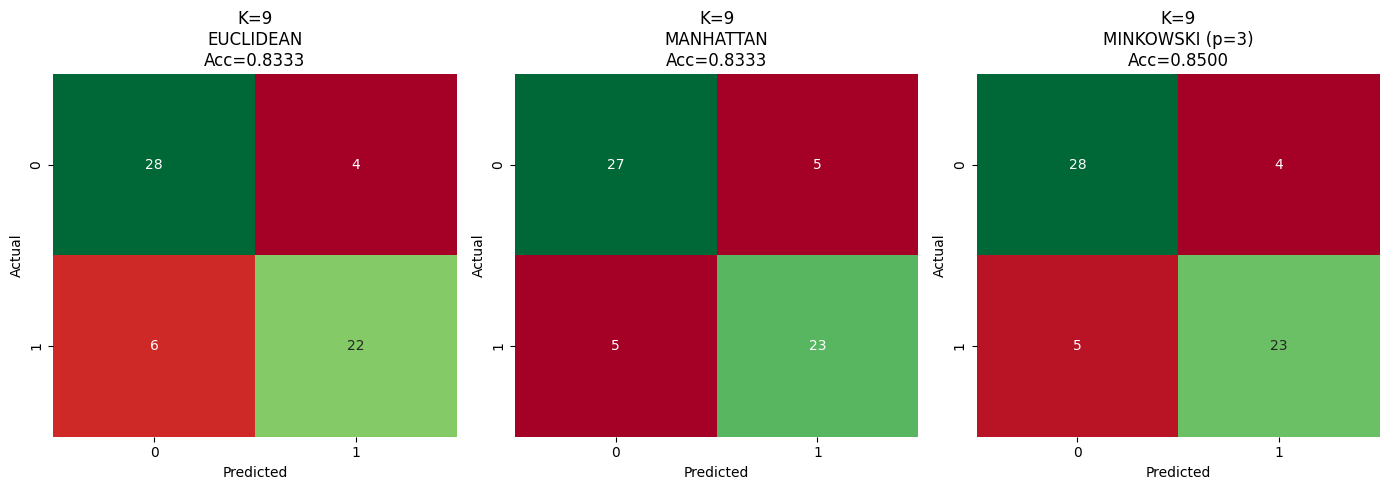


HASIL EVALUASI K = 9

EUCLIDEAN
----------------------------------------
Accuracy  : 0.8333
Precision : 0.8462
Recall    : 0.7857
F1-Score  : 0.8148

MANHATTAN
----------------------------------------
Accuracy  : 0.8333
Precision : 0.8214
Recall    : 0.8214
F1-Score  : 0.8214

MINKOWSKI (p=3)
----------------------------------------
Accuracy  : 0.8500
Precision : 0.8519
Recall    : 0.8214
F1-Score  : 0.8364


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
k_final = 9

metrics = [
    {'name': 'EUCLIDEAN', 'metric': 'euclidean', 'p': 2},
    {'name': 'MANHATTAN', 'metric': 'manhattan', 'p': 1},
    {'name': 'MINKOWSKI (p=3)', 'metric': 'minkowski', 'p': 3}
]

fig, axes = plt.subplots(1, len(metrics), figsize=(14, 5))

results = {}

for i, config in enumerate(metrics):

    knn = KNeighborsClassifier(
        n_neighbors=k_final,
        metric=config['metric'],
        p=config['p'],
        weights='distance'
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    results[config['name']] = {
        'accuracy': acc,
        'report': classification_report(
            y_test,
            y_pred,
            output_dict=True
        )
    }

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='RdYlGn',
        ax=axes[i],
        cbar=False
    )

    axes[i].set_title(
        f"K={k_final}\n{config['name']}\nAcc={acc:.4f}"
    )

    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"HASIL EVALUASI K = {k_final}")
print("="*60)

for name, data in results.items():

    report = data['report']

    print(f"\n{name}")
    print("-"*40)
    print(f"Accuracy  : {data['accuracy']:.4f}")
    print(f"Precision : {report['1']['precision']:.4f}")
    print(f"Recall    : {report['1']['recall']:.4f}")
    print(f"F1-Score  : {report['1']['f1-score']:.4f}")

In [ ]:
from sklearn.metrics import accuracy_score
metrics = [
    ('euclidean', {}),
    ('manhattan', {}),
    ('minkowski', {'p': 3}),
]

for metric, extra_params in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric,
        weights='distance',
        **extra_params
    )

    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    label = f"{metric.upper()} (p=3)" if extra_params else metric.upper()
    print(label)
    print(y_pred[:20])
    print()

EUCLIDEAN
[0 0 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1]

MANHATTAN
[0 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 1]

MINKOWSKI (p=3)
[0 0 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1]



HASIL FINAL MODEL
Algoritma : Weighted KNN
Metrik    : Manhattan
K         : 9
Accuracy  : 0.8333
Precision : 0.8214
Recall    : 0.8214
F1-Score  : 0.8214


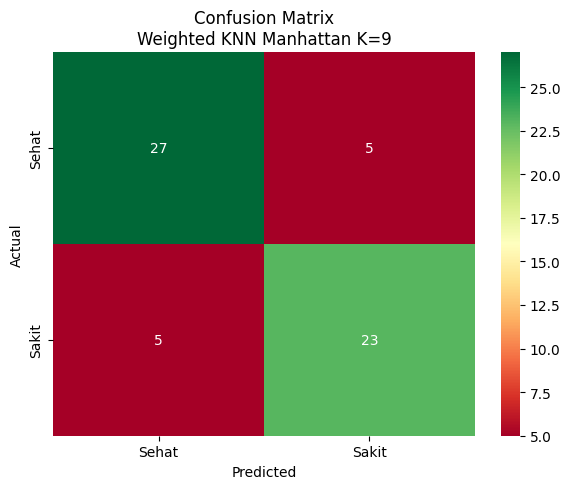

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

knn_final = KNeighborsClassifier(
    n_neighbors=9,
    metric='manhattan',
    weights='distance'
)

knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)

acc       = accuracy_score(y_test, y_pred)
report    = classification_report(y_test, y_pred, output_dict=True)
cm        = confusion_matrix(y_test, y_pred)

print("="*50)
print("HASIL FINAL MODEL")
print("Algoritma : Weighted KNN")
print("Metrik    : Manhattan")
print("K         : 9")
print("="*50)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {report['1']['precision']:.4f}")
print(f"Recall    : {report['1']['recall']:.4f}")
print(f"F1-Score  : {report['1']['f1-score']:.4f}")
print("="*50)


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='RdYlGn',
    xticklabels=['Sehat', 'Sakit'],
    yticklabels=['Sehat', 'Sakit']
)
plt.title(f'Confusion Matrix\nWeighted KNN Manhattan K=9')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Model                        Acc   Prec    Rec     F1
Weighted KNN Manhattan K=9 0.8333 0.8214 0.8214 0.8214
Random Forest 100 Trees   0.8167 0.8400 0.7500 0.7925


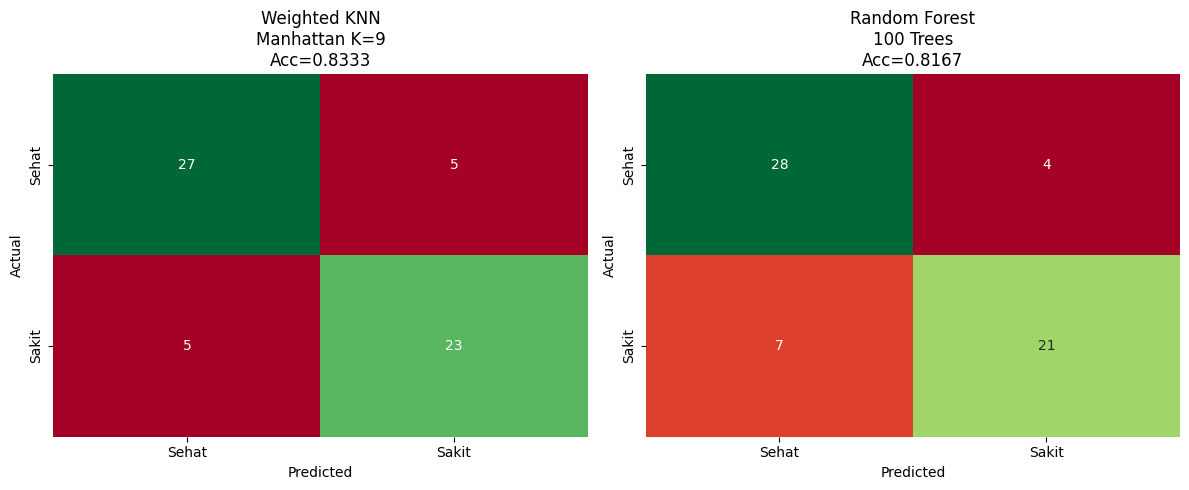

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

knn_final = KNeighborsClassifier(
    n_neighbors=9,
    metric='manhattan',
    weights='distance'
)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)


models = {
    'Weighted KNN\nManhattan K=9': y_pred_knn,
    'Random Forest\n100 Trees': y_pred_rf
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

print("="*55)
print(f"{'Model':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("="*55)

for i, (name, y_pred) in enumerate(models.items()):
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm     = confusion_matrix(y_test, y_pred)

    prec = report['1']['precision']
    rec  = report['1']['recall']
    f1   = report['1']['f1-score']

    print(f"{name.replace(chr(10), ' '):<25} {acc:>6.4f} {prec:>6.4f} {rec:>6.4f} {f1:>6.4f}")

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='RdYlGn',
        ax=axes[i],
        xticklabels=['Sehat', 'Sakit'],
        yticklabels=['Sehat', 'Sakit'],
        cbar=False
    )
    axes[i].set_title(f'{name}\nAcc={acc:.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

print("="*55)
plt.tight_layout()
plt.show()

AI CONFIDENCE SCORING — Weighted KNN Manhattan K=9
No    Actual     Prediksi     Conf Sehat   Conf Sakit   Confidence Status
---------------------------------------------------------------------------
0     SEHAT      SEHAT            1.0000       0.0000       1.0000 ✅ BENAR
1     SEHAT      SEHAT            1.0000       0.0000       1.0000 ✅ BENAR
2     SEHAT      SAKIT            0.4622       0.5378       0.5378 ❌ SALAH
3     SEHAT      SAKIT            0.4710       0.5290       0.5290 ❌ SALAH
4     SEHAT      SEHAT            0.7872       0.2128       0.7872 ✅ BENAR
5     SEHAT      SEHAT            1.0000       0.0000       1.0000 ✅ BENAR
6     SAKIT      SAKIT            0.1989       0.8011       0.8011 ✅ BENAR
7     SEHAT      SEHAT            1.0000       0.0000       1.0000 ✅ BENAR
8     SAKIT      SEHAT            0.5931       0.4069       0.5931 ❌ SALAH
9     SEHAT      SEHAT            0.6816       0.3184       0.6816 ✅ BENAR
10    SAKIT      SAKIT            0.0963       0.

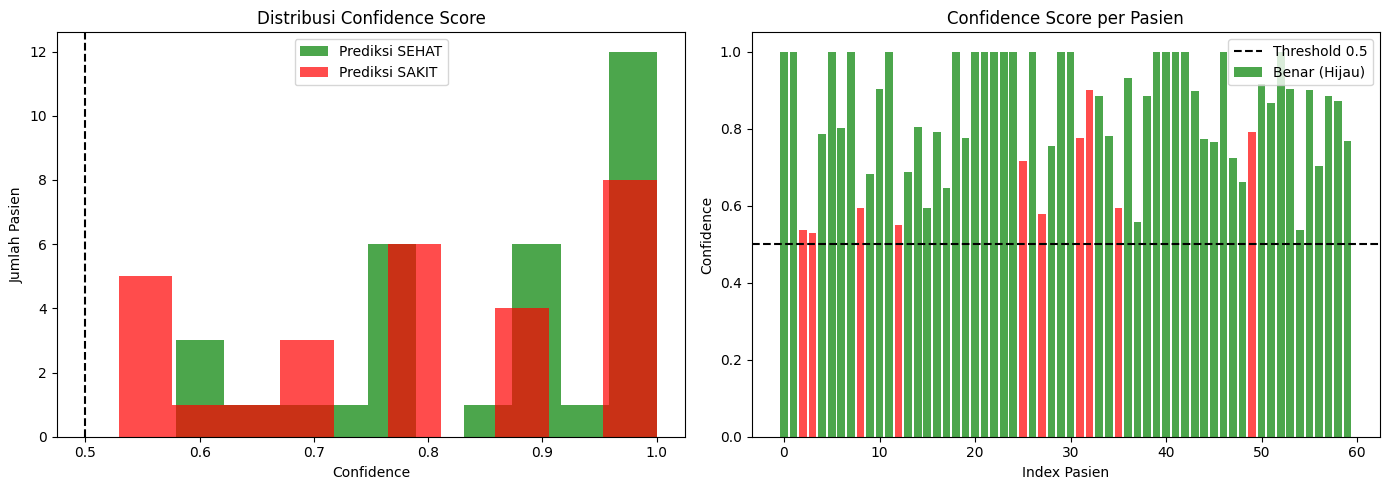

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_proba = knn_final.predict_proba(X_test_scaled)
y_pred  = knn_final.predict(X_test_scaled)

df_result = pd.DataFrame({
    'Actual'          : y_test.values,
    'Predicted'       : y_pred,
    'Conf_Sehat'      : y_proba[:, 0].round(4),
    'Conf_Sakit'      : y_proba[:, 1].round(4),
    'Confidence'      : np.max(y_proba, axis=1).round(4),
    'Status'          : ['✅ BENAR' if a == p else '❌ SALAH'
                         for a, p in zip(y_test.values, y_pred)]
})
df_result['Prediksi_Label'] = df_result['Predicted'].map({
    0: 'SEHAT', 1: 'SAKIT'
})
df_result['Actual_Label'] = df_result['Actual'].map({
    0: 'SEHAT', 1: 'SAKIT'
})
print("="*75)
print("AI CONFIDENCE SCORING — Weighted KNN Manhattan K=9")
print("="*75)
print(f"{'No':<5} {'Actual':<10} {'Prediksi':<10} {'Conf Sehat':>12} {'Conf Sakit':>12} {'Confidence':>12} {'Status'}")
print("-"*75)
for i, row in df_result.iterrows():
    print(f"{i:<5} {row['Actual_Label']:<10} {row['Prediksi_Label']:<10} "
          f"{row['Conf_Sehat']:>12.4f} {row['Conf_Sakit']:>12.4f} "
          f"{row['Confidence']:>12.4f} {row['Status']}")

print("\n" + "="*75)
print("STATISTIK CONFIDENCE")
print("="*75)
print(f"Rata-rata confidence prediksi BENAR : "
      f"{df_result[df_result['Status']=='✅ BENAR']['Confidence'].mean():.4f}")
print(f"Rata-rata confidence prediksi SALAH : "
      f"{df_result[df_result['Status']=='❌ SALAH']['Confidence'].mean():.4f}")
print(f"Confidence tertinggi : {df_result['Confidence'].max():.4f}")
print(f"Confidence terendah  : {df_result['Confidence'].min():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df_result[df_result['Predicted']==0]['Confidence'],
    bins=10, alpha=0.7, color='green', label='Prediksi SEHAT'
)
axes[0].hist(
    df_result[df_result['Predicted']==1]['Confidence'],
    bins=10, alpha=0.7, color='red', label='Prediksi SAKIT'
)
axes[0].set_title('Distribusi Confidence Score')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].legend()
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')

colors = ['green' if s == '✅ BENAR' else 'red' for s in df_result['Status']]

axes[1].bar(range(len(df_result)), df_result['Confidence'], color=colors, alpha=0.7)
axes[1].axhline(y=0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[1].set_title('Confidence Score per Pasien')
axes[1].set_xlabel('Index Pasien')
axes[1].set_ylabel('Confidence')
axes[1].legend(['Threshold 0.5', 'Benar (Hijau)', 'Salah (Merah)'])

plt.tight_layout()
plt.show()